<div style="text-align: center; margin-bottom: 2rem; font-family: sans-serif;">
  <hr style="border: none; border-top: 1px solid #ccc; margin-bottom: 1rem;">
  <p style="margin: 4px 0; font-size: 1.2em; font-weight: bold;">EN3160 Assignment 1: Intensity Transformations and Neighborhood Filtering</p>
  <p style="margin: 4px 0;">230033J Amarasinghe A.A.D.K.</p>
  <p style="margin: 4px 0;">13 September 2026</p>
  <p style="margin: 4px 0;"><a href="https://github.com/your-username/repository">https://github.com/Dulith-Kavinda/Intensity_Transformations_and_Neighborhood_Filtering</a></p>
  <hr style="border: none; border-top: 1px solid #ccc; margin-top: 1rem;">
</div>

In [78]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

#### Load Images

In [79]:
def load_image(path, condition):
    match condition:
        case True:
            img = cv.imread(path, cv.IMREAD_GRAYSCALE)
        case False:
            img = cv.imread(path)
    if img is None:
        raise FileNotFoundError(f"Image not found at {path}")
    return img

#### Task 01

In [80]:
def intensity_transform(im, breakpoints):
    breakpoints = np.array(breakpoints, dtype=np.float64)
    xs, ys = breakpoints[:, 0], breakpoints[:, 1]
    lut = np.interp(np.arange(256), xs, ys).astype(np.uint8)
    out = cv.LUT(im, lut)
    return out, lut

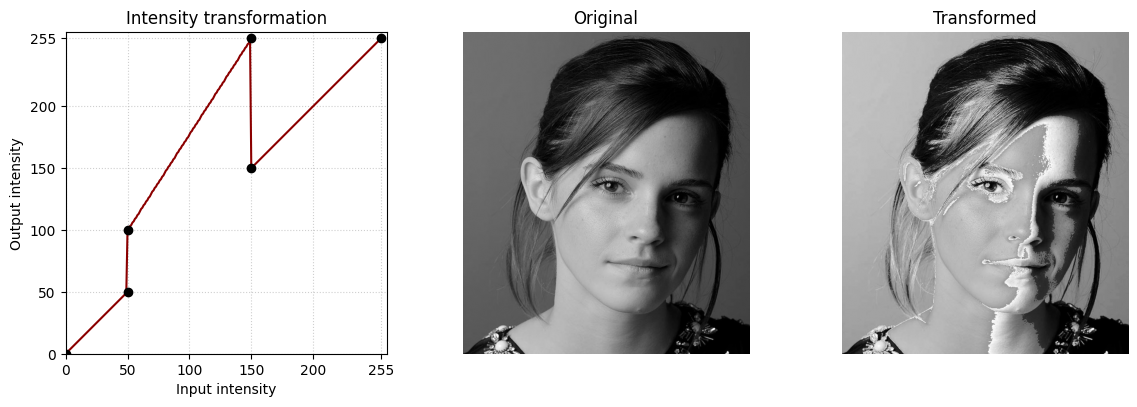

In [81]:
def task_01():
    img = load_image("images/q1.jpeg", True)

    breakpoints = np.array([
        [0,   0],
        [50,  50],
        [50, 100],
        [150, 255],
        [150, 150],
        [255, 255],
    ])

    out, lut = intensity_transform(img, breakpoints)
    ticks = [0, 50, 100, 150, 200, 255] 
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].plot(np.arange(256), lut, color="darkred")
    ax[0].plot(breakpoints[:, 0], breakpoints[:, 1], "ko")
    ax[0].set_xlim(0, 260)
    ax[0].set_ylim(0, 260)
    ax[0].set_xticks(ticks)
    ax[0].set_yticks(ticks)
    ax[0].set_xlabel("Input intensity")
    ax[0].set_ylabel("Output intensity")
    ax[0].set_title("Intensity transformation")
    ax[0].set_aspect("equal")
    ax[0].grid(True, linestyle=":", alpha=0.6)
    ax[1].imshow(img, cmap="gray")
    ax[1].set_title("Original")
    ax[1].axis("off")
    ax[2].imshow(out, cmap="gray")
    ax[2].set_title("Transformed")
    ax[2].axis("off")
    plt.tight_layout()
    plt.show()


task_01()

* Here we can see 50-150 range we have used high intensity transformation. 0-50 and 150-255 values are not change they are same as before but now we cand clearly visible boundy of 50-150 range and other normal range. 

#### Task 02

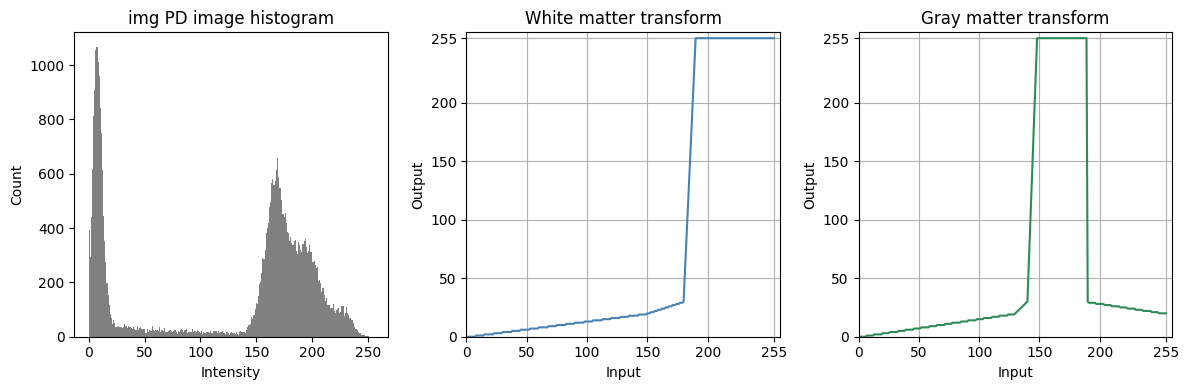

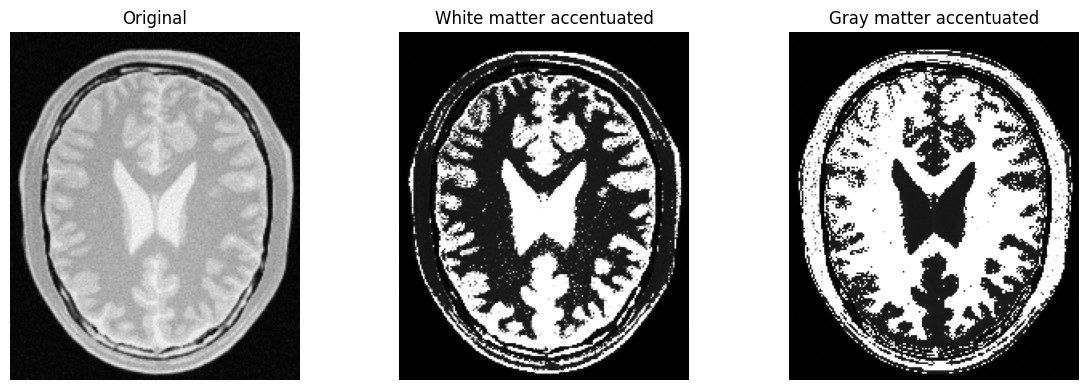

In [82]:
def task_02():
    img = load_image("images/q2.jpeg", True)

    # White matter: accentuate 190-250 suppress everything else
    breakpoints_white = np.array([
        [0,   0],
        [150, 20],
        [180, 30],
        [190, 255],
        [220, 255],
        [255, 255],
    ])
    
    # Gray matter: accentuate 140-190, suppress everything else
    breakpoints_gray = np.array([
        [0,   0],
        [130, 20],
        [140, 30],
        [148, 255],
        [190, 255],
        [190, 30],
        [255, 20],
    ])

    white_img, white_lut = intensity_transform(img, breakpoints_white)
    gray_img, gray_lut = intensity_transform(img, breakpoints_gray)

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].hist(img.ravel(), bins=256, range=(0, 255), color="gray")
    ax[0].set_title("img PD image histogram")
    ax[0].set_xlabel("Intensity")
    ax[0].set_ylabel("Count")

    ticks = [0, 50, 100, 150, 200, 255] 

    ax[1].plot(white_lut, color="steelblue")
    ax[1].set_title("White matter transform")
    ax[2].plot(gray_lut, color="seagreen")
    ax[2].set_title("Gray matter transform")

    for a in ax[1:]:
        a.set_xticks(ticks)
        a.set_yticks(ticks)
        a.set_xlim(0, 260)
        a.set_ylim(0, 260)
        a.set_xlabel("Input")
        a.set_ylabel("Output")
        a.grid(True)
        
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, im, title in zip(
        axes,
        [img, white_img, gray_img],
        ["Original", "White matter accentuated", "Gray matter accentuated"],
    ):
        ax.imshow(im, cmap="gray")
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

task_02()

* By looking this histogramme we can say 0 to nearly 25 are not brain tissues and also 25 to 148 also near to zero so brain intensities nearly start from 150 and when we show white matters we can show high intensity pixels clearly(190-255) and suppress others and also in gray matter we have to show low intensities pixels represent brain with band pass filter(140-190).

#### Task 03


Gamma value used: 0.6


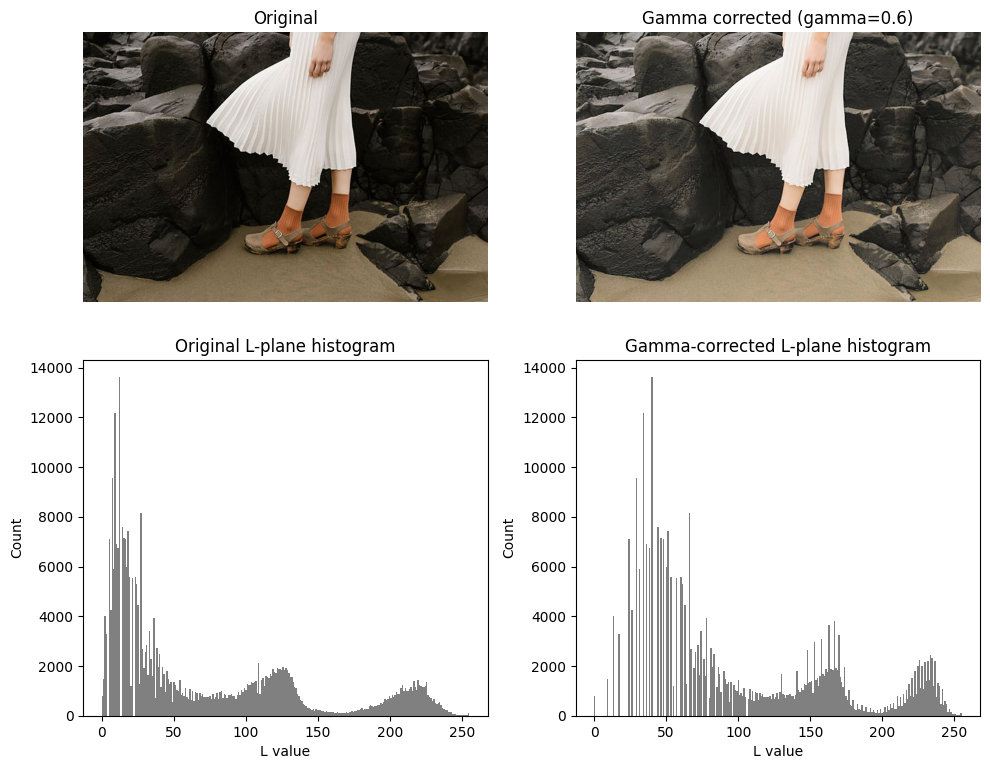

In [83]:
def task_03():
    img= load_image("images/q3.jpeg", False)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
    L, a, b = cv.split(lab)

    gamma = 0.6
    L_norm = L.astype(np.float64) / 255.0
    L_gamma = np.power(L_norm, gamma) * 255.0
    L_gamma = np.clip(L_gamma, 0, 255).astype(np.uint8)

    lab_corrected = cv.merge([L_gamma, a, b])
    img_corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)
    img_corrected_rgb = cv.cvtColor(img_corrected, cv.COLOR_BGR2RGB)

    print(f"Gamma value used: {gamma}")

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes[0,0].imshow(img_rgb)
    axes[0,0].set_title("Original")
    axes[0,0].axis("off")
    axes[0,1].imshow(img_corrected_rgb)
    axes[0,1].set_title(f"Gamma corrected (gamma={gamma})")
    axes[0,1].axis("off")
    axes[1,0].hist(L.ravel(), bins=256, range=(0, 255), color="gray")
    axes[1,0].set_title("Original L-plane histogram")
    axes[1,1].hist(L_gamma.ravel(), bins=256, range=(0, 255), color="gray")
    axes[1,1].set_title("Gamma-corrected L-plane histogram")
    for ax in axes[1,:]:
        ax.set_xlabel("L value")
        ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

task_03()

* In the histogrammes we can see high count of low intensity pixels so we have to map darker pixels to wider range to do that we have to use Gamma < 1 value. Here I used 0.6 because it is commonly using fo task like this and it clearly map this image.

#### Task 04

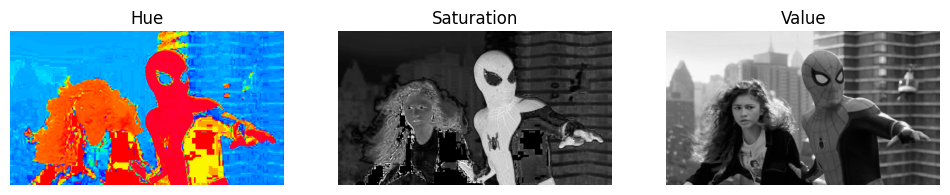

a = 0.5, sigma = 70


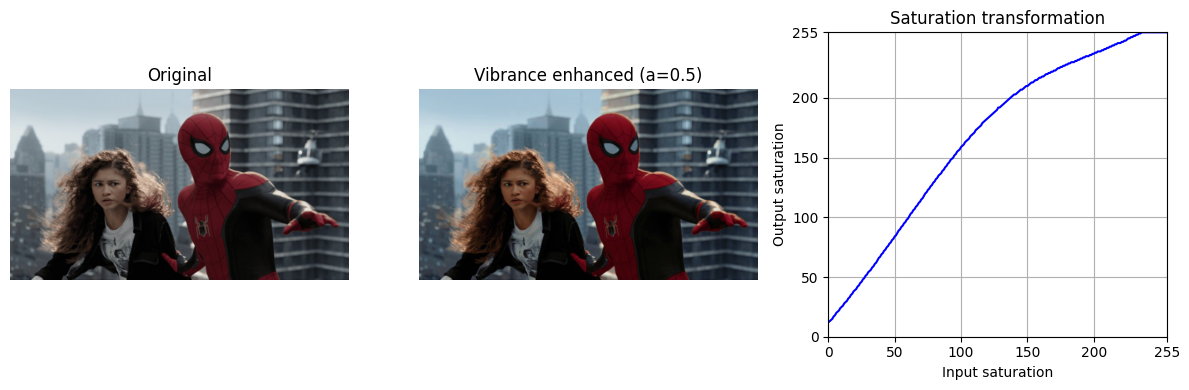

In [84]:
def vibrance_transform(x, a, sigma=70):
    x = x.astype(np.float64)
    boosted = x + a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2 * sigma ** 2))
    return np.clip(boosted, 0, 255).astype(np.uint8)

def task_04():
    img = load_image("images/q4.jpeg", False)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
    h, s, v = cv.split(hsv)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(h, cmap='hsv')
    plt.title("Hue")
    plt.axis("off")
    plt.subplot(1,3,2)
    plt.imshow(s, cmap='gray')
    plt.title("Saturation")
    plt.axis("off")
    plt.subplot(1,3,3)
    plt.imshow(v, cmap='gray')
    plt.title("Value")
    plt.axis("off")
    plt.show()

    a = 0.5  # [0, 1]
    sigma = 70
    s_boosted = vibrance_transform(s, a, sigma)
    hsv_boosted = cv.merge([h, s_boosted, v])
    img_vibrant = cv.cvtColor(hsv_boosted, cv.COLOR_HSV2BGR)
    img_vibrant_rgb = cv.cvtColor(img_vibrant, cv.COLOR_BGR2RGB)
    print(f"a = {a}, sigma = {sigma}")

    xs = np.arange(256)
    ys = vibrance_transform(xs, a, sigma)
    
    ticks = [0, 50, 100, 150, 200, 255] 
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    plt.xticks(ticks)
    plt.yticks(ticks)
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(img_vibrant_rgb)
    axes[1].set_title(f"Vibrance enhanced (a={a})")
    axes[1].axis("off")
    axes[2].plot(xs, ys, color="blue")
    axes[2].set_title("Saturation transformation")
    axes[2].set_xlabel("Input saturation")
    axes[2].set_ylabel("Output saturation")
    axes[2].set_xlim(0, 255)
    axes[2].set_ylim(0, 255)
    axes[2].grid(True)
    plt.tight_layout()
    plt.show()

task_04()

* To enhance vibrance the image is first split into hue, saturation and value planes. After used the given intensity transformation to the saturation plane which boosts mid range saturation values while keeping extremes controlled. By adjusting the parameter Alpha got better visually pleasing image as Alpha = 0.5 image afte three planes are recombined.

#### Task 05

In [85]:
def histogram_equalize(im):
    hist, _ = np.histogram(im.ravel(), bins=256, range=(0, 256))
    cdf = np.cumsum(hist).astype(np.float64)
    total_pixels = im.size
    lut = np.round((cdf / total_pixels) * 255.0)
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return cv.LUT(im, lut)


The transformation function is:
y = T(x) = round( C(x) * (L - 1)/(MN) )

where:
- x = input pixel intensity  
- y = output (equalized) intensity  
- L = number of intensity levels (for 8‑bit images, L = 256)  
- C(x) = cumulative distribution function (CDF) of the histogram
- MN = num of pixels

The CDF is defined as:
C(x) = Σ (from i = 0 to x) p(i)

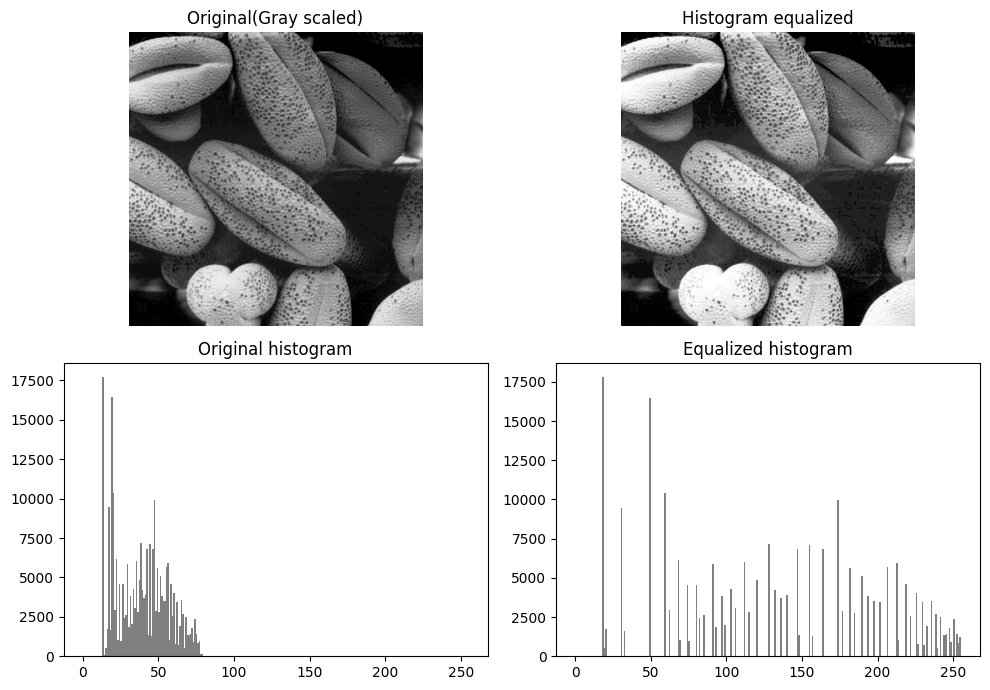

In [86]:

def task_05():
    img = load_image("images/q5.tif", True)

    img_eq = histogram_equalize(img)

    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    axes[0,0].imshow(img, cmap="gray")
    axes[0,0].set_title("Original(Gray scaled)")
    axes[0,0].axis("off")
    axes[0,1].imshow(img_eq, cmap="gray")
    axes[0,1].set_title("Histogram equalized")
    axes[0,1].axis("off")
    axes[1,0].hist(img.ravel(), bins=256, range=(0, 255), color="gray")
    axes[1,0].set_title("Original histogram")
    axes[1,1].hist(img_eq.ravel(), bins=256, range=(0, 255), color="gray")
    axes[1,1].set_title("Equalized histogram")
    plt.tight_layout()
    plt.show()

task_05()

#### Task 06

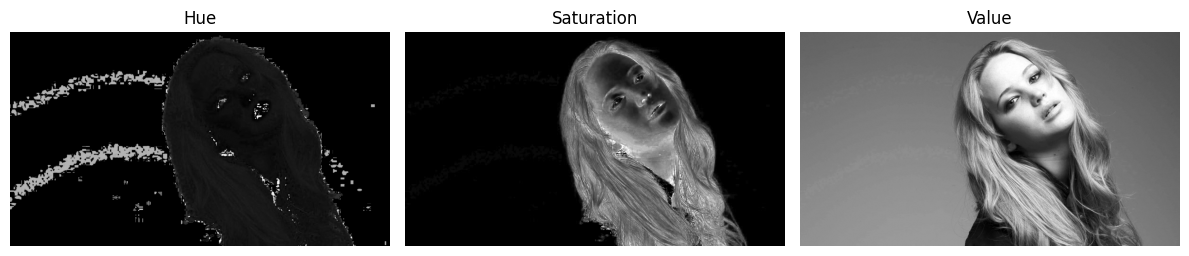

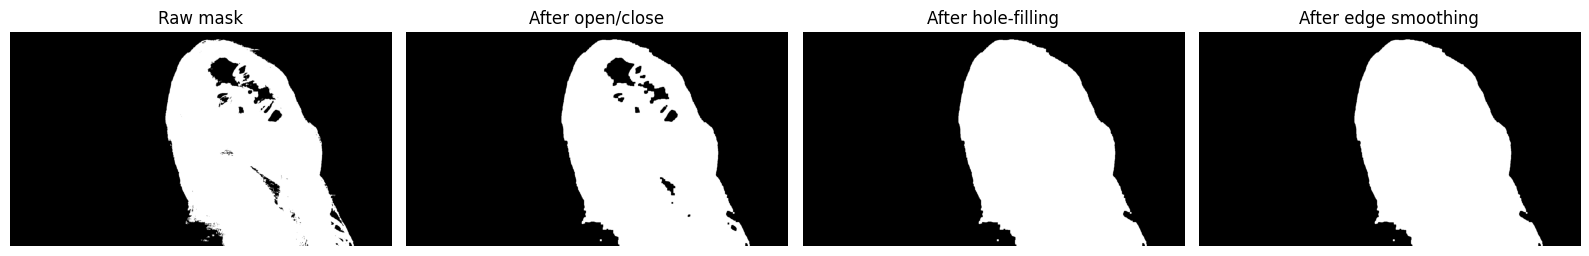

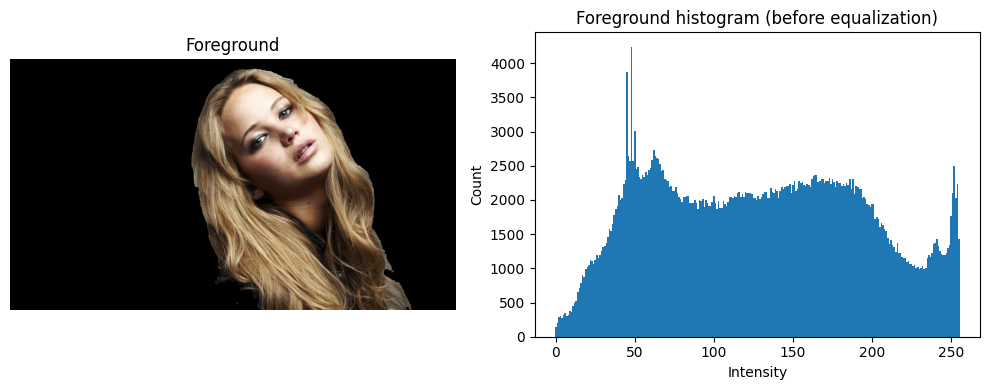

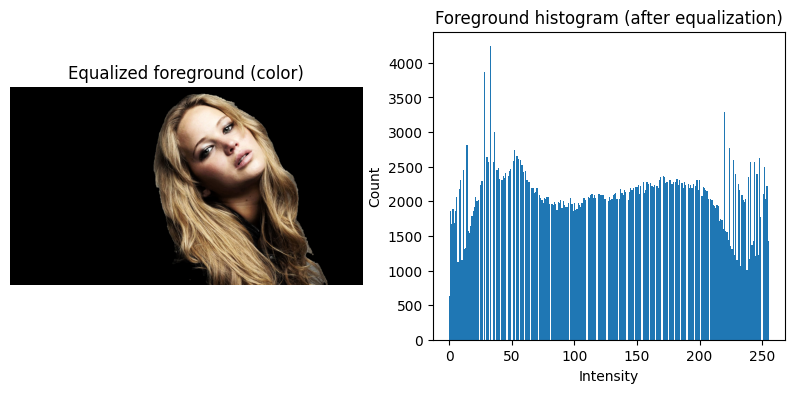

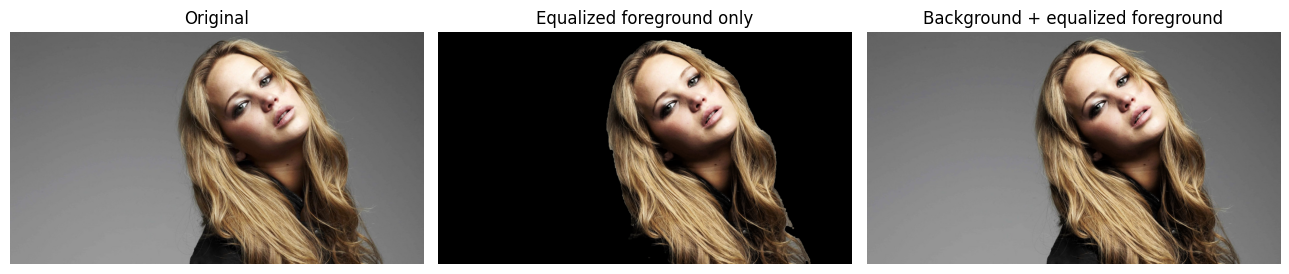

In [87]:
def task_06():
    img_bgr = load_image('images/q6.jpeg', False)
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
    hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
    h, s, v = cv.split(hsv)

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    for a, plane, title in zip(ax, [h, s, v], ['Hue', 'Saturation', 'Value']):
        a.imshow(plane, cmap='gray')
        a.set_title(title)
        a.axis('off')
    plt.tight_layout()
    plt.show()

    _, raw_mask = cv.threshold(s, 40, 255, cv.THRESH_BINARY)

    kernel = np.ones((7, 7), np.uint8)
    mask = cv.morphologyEx(raw_mask, cv.MORPH_CLOSE, kernel)
    mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)
    contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    mask_filled = np.zeros_like(mask)
    cv.drawContours(mask_filled, contours, -1, 255, thickness=cv.FILLED)

    mask_blurred = cv.GaussianBlur(mask_filled, (9, 9), 0)
    _, mask_smooth = cv.threshold(mask_blurred, 127, 255, cv.THRESH_BINARY)
    fig, ax = plt.subplots(1, 4, figsize=(16, 4))
    ax[0].imshow(raw_mask, cmap='gray'); ax[0].set_title('Raw mask'); ax[0].axis('off')
    ax[1].imshow(mask, cmap='gray'); ax[1].set_title('After open/close'); ax[1].axis('off')
    ax[2].imshow(mask_filled, cmap='gray'); ax[2].set_title('After hole-filling'); ax[2].axis('off')
    ax[3].imshow(mask_smooth, cmap='gray'); ax[3].set_title('After edge smoothing'); ax[3].axis('off')
    plt.tight_layout()
    plt.show()

    mask = mask_smooth
    mask_inv = cv.bitwise_not(mask)
    foreground_v = cv.bitwise_and(v, v, mask=mask)
    background_v = cv.bitwise_and(v, v, mask=mask_inv)

    foreground_color = cv.bitwise_and(img_rgb, img_rgb, mask=mask)
    background_color = cv.bitwise_and(img_rgb, img_rgb, mask=mask_inv)

    fg_pixels = v[mask == 255]
    hist_fg, bins = np.histogram(fg_pixels, bins=256, range=(0, 256))

    cdf = np.cumsum(hist_fg)
    L = 256
    cdf_normalized = (L - 1) * cdf / cdf[-1]
    lut = np.round(cdf_normalized).astype(np.uint8)

    equalized_fg_v = np.zeros_like(v)
    equalized_fg_v[mask == 255] = lut[v[mask == 255]]
    eq_fg_pixels = equalized_fg_v[mask == 255]
    hist_eq, _ = np.histogram(eq_fg_pixels, bins=256, range=(0, 256))

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(foreground_color);
    ax[0].set_title('Foreground');
    ax[0].axis('off')
    ax[1].bar(range(256), hist_fg, width=1)
    ax[1].set_title('Foreground histogram (before equalization)')
    ax[1].set_xlabel('Intensity');
    ax[1].set_ylabel('Count')
    plt.tight_layout()
    plt.show()

    hsv_fg_eq = cv.merge([h, s, equalized_fg_v])
    fg_eq_bgr = cv.cvtColor(hsv_fg_eq, cv.COLOR_HSV2BGR)
    fg_eq_rgb = cv.cvtColor(fg_eq_bgr, cv.COLOR_BGR2RGB)
    fg_eq_rgb_masked = cv.bitwise_and(fg_eq_rgb, fg_eq_rgb, mask=mask)

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(fg_eq_rgb_masked)
    ax[0].set_title('Equalized foreground (color)')
    ax[0].axis('off')
    ax[1].bar(range(256), hist_eq, width=1)
    ax[1].set_title('Foreground histogram (after equalization)')
    ax[1].set_xlabel('Intensity');
    ax[1].set_ylabel('Count')
    plt.show()

    combined_v = cv.bitwise_or(equalized_fg_v, background_v)
    hsv_result = cv.merge([h, s, combined_v])
    result_bgr = cv.cvtColor(hsv_result, cv.COLOR_HSV2BGR)
    result_rgb = cv.cvtColor(result_bgr, cv.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, 3, figsize=(13, 4))
    ax[0].imshow(img_rgb); ax[0].set_title('Original');
    ax[0].axis('off')
    ax[1].imshow(fg_eq_rgb_masked); ax[1].set_title('Equalized foreground only');
    ax[1].axis('off')
    ax[2].imshow(result_rgb); ax[2].set_title('Background + equalized foreground');
    ax[2].axis('off')
    plt.tight_layout()
    plt.show()

task_06()

#### Task 07

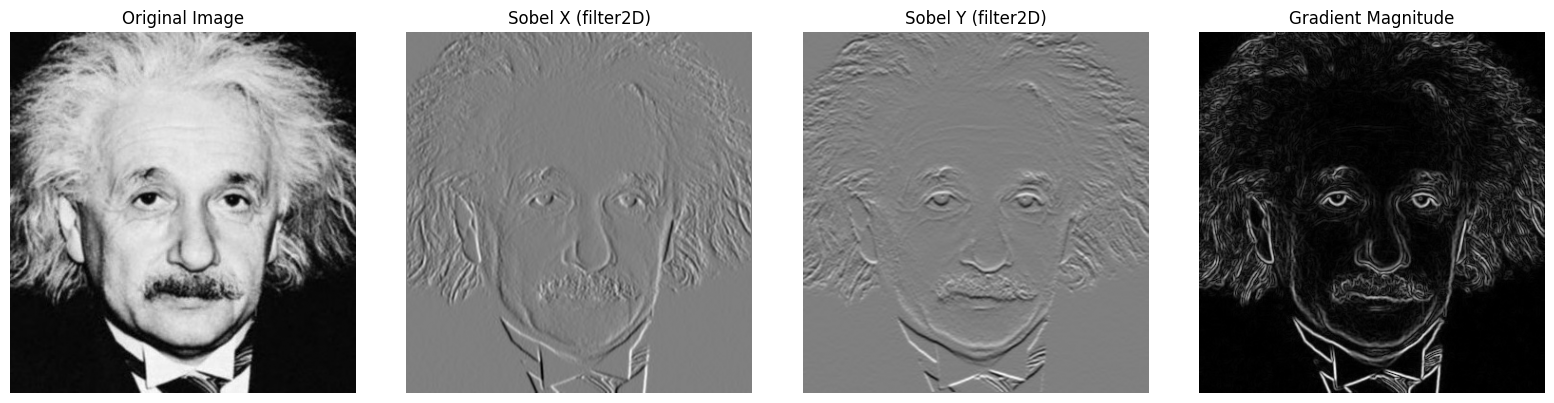

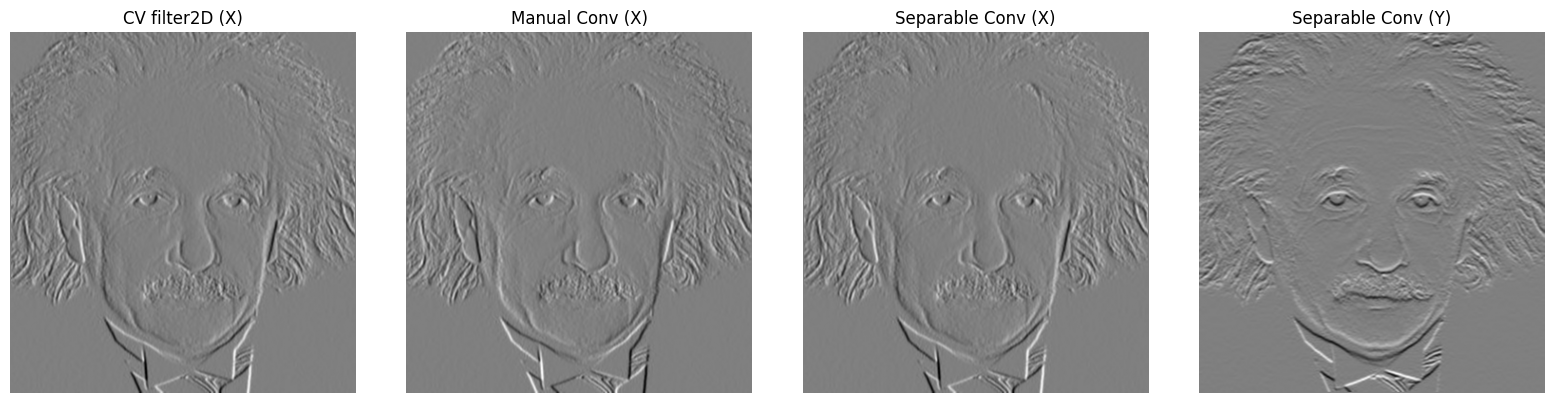

In [88]:
def task_07():
    img_gray = load_image('images/q7.jpeg', True)  # grayscale Einstein image

    sobel_x_kernel = np.array([[ 1,  0, -1],
                                [ 2,  0, -2],
                                [ 1,  0, -1]], dtype=np.float32)

    sobel_y_kernel = np.array([[ 1,  2,  1],
                                [ 0,  0,  0],
                                [-1, -2, -1]], dtype=np.float32)

    sobel_x_cv = cv.filter2D(img_gray.astype(np.float32), -1, sobel_x_kernel)
    sobel_y_cv = cv.filter2D(img_gray.astype(np.float32), -1, sobel_y_kernel)
    grad_mag_cv = np.sqrt(sobel_x_cv**2 + sobel_y_cv**2)

    limit = max(np.abs(sobel_x_cv).max(), np.abs(sobel_y_cv).max())
    
    fig, ax = plt.subplots(1, 4, figsize=(16, 4))
    ax[0].imshow(img_gray, cmap='gray')
    ax[0].set_title('Original Image')
    ax[0].axis('off')
    ax[1].imshow(sobel_x_cv, cmap='gray', vmin=-limit, vmax=limit)
    ax[1].set_title('Sobel X (filter2D)')
    ax[1].axis('off')
    ax[2].imshow(sobel_y_cv, cmap='gray', vmin=-limit, vmax=limit)
    ax[2].set_title('Sobel Y (filter2D)')
    ax[2].axis('off')
    ax[3].imshow(grad_mag_cv, cmap='gray')
    ax[3].set_title('Gradient Magnitude')
    ax[3].axis('off')

    plt.tight_layout()
    plt.show()

    def convolve2d_manual(img, kernel):
        img = img.astype(np.float32)
        kh, kw = kernel.shape
        pad_h, pad_w = kh // 2, kw // 2
        padded = cv.copyMakeBorder(img, pad_h, pad_h, pad_w, pad_w, cv.BORDER_REPLICATE)
        kernel_flipped = np.flipud(np.fliplr(kernel))
        out = np.zeros_like(img, dtype=np.float32)
        H, W = img.shape
        for i in range(H):
            for j in range(W):
                region = padded[i:i+kh, j:j+kw]
                out[i, j] = np.sum(region * kernel_flipped)
        return out

    sobel_x_manual = convolve2d_manual(img_gray, sobel_x_kernel)
    sobel_y_manual = convolve2d_manual(img_gray, sobel_y_kernel)

    col_smooth = np.array([[1], [2], [1]], dtype=np.float32)     # vertical smoothing
    row_deriv  = np.array([[1, 0, -1]], dtype=np.float32)        # horizontal derivative
    sobel_x_sep = cv.filter2D(img_gray.astype(np.float32), -1, col_smooth)
    sobel_x_sep = cv.filter2D(sobel_x_sep, -1, row_deriv)
    row_smooth = np.array([[1, 2, 1]], dtype=np.float32)
    col_deriv  = np.array([[1], [0], [-1]], dtype=np.float32)
    sobel_y_sep = cv.filter2D(img_gray.astype(np.float32), -1, row_smooth)
    sobel_y_sep = cv.filter2D(sobel_y_sep, -1, col_deriv)

    fig, ax = plt.subplots(1, 4, figsize=(16, 4))
    ax[0].imshow(sobel_x_cv, cmap='gray', vmin=-limit, vmax=limit)
    ax[0].set_title('CV filter2D (X)')
    ax[0].axis('off')
    ax[1].imshow(sobel_x_manual, cmap='gray', vmin=-limit, vmax=limit)
    ax[1].set_title('Manual Conv (X)')
    ax[1].axis('off')
    ax[2].imshow(sobel_x_sep, cmap='gray', vmin=-limit, vmax=limit)
    ax[2].set_title('Separable Conv (X)')
    ax[2].axis('off')
    ax[3].imshow(sobel_y_sep, cmap='gray', vmin=-limit, vmax=limit)
    ax[3].set_title('Separable Conv (Y)')
    ax[3].axis('off')

    plt.tight_layout()
    plt.show()

task_07()

* Here Sobel edge detection to highlight image boundaries. It compares three mathematically equivalent methods OpenCV's optimized cv.filter2D, a manual 2D convolution loop and highly efficient 1D separable filtering. which demonstrates how splitting and it reduces computational cost.

#### Task 08

im01small.png: nearest neighbor SSD = 136.269, bilinear SSD = 115.126


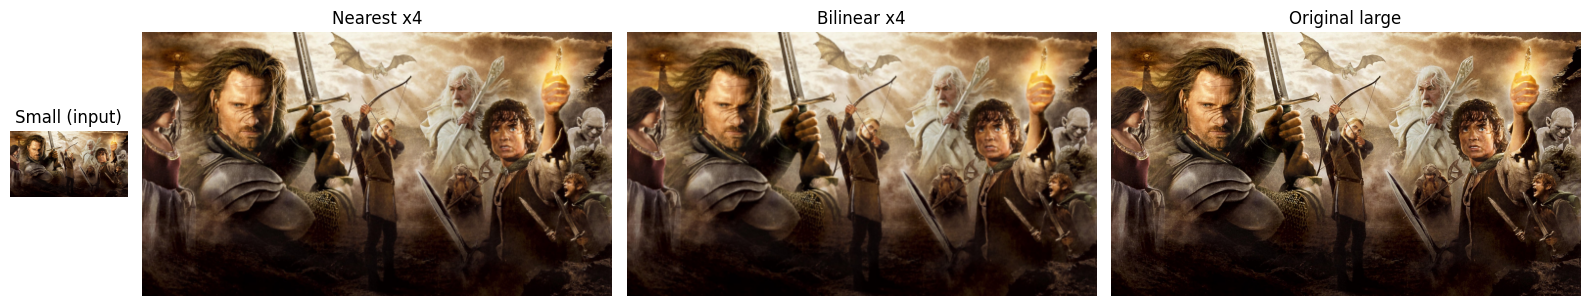

im02small.png: nearest neighbor SSD = 26.446, bilinear SSD = 18.397


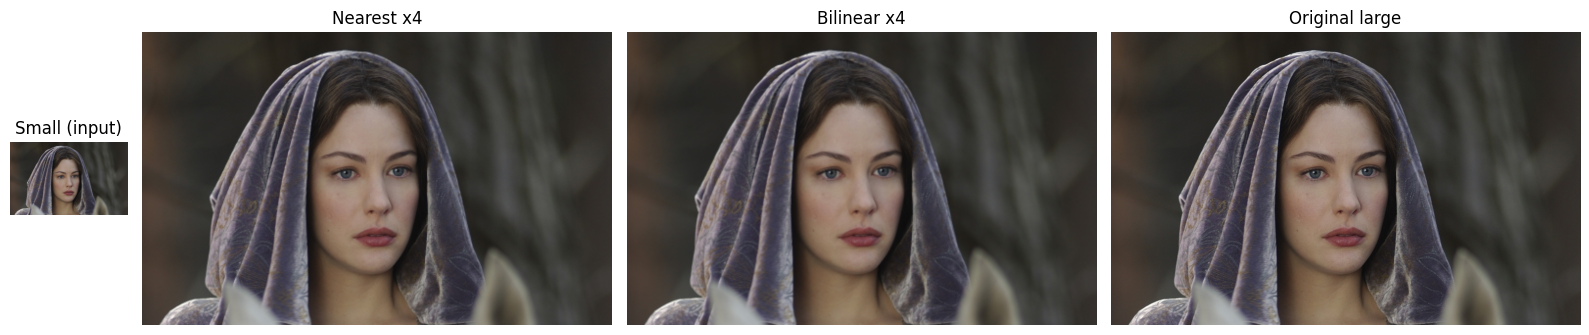

im03small.png: nearest neighbor SSD = 67.582, bilinear SSD = 51.320


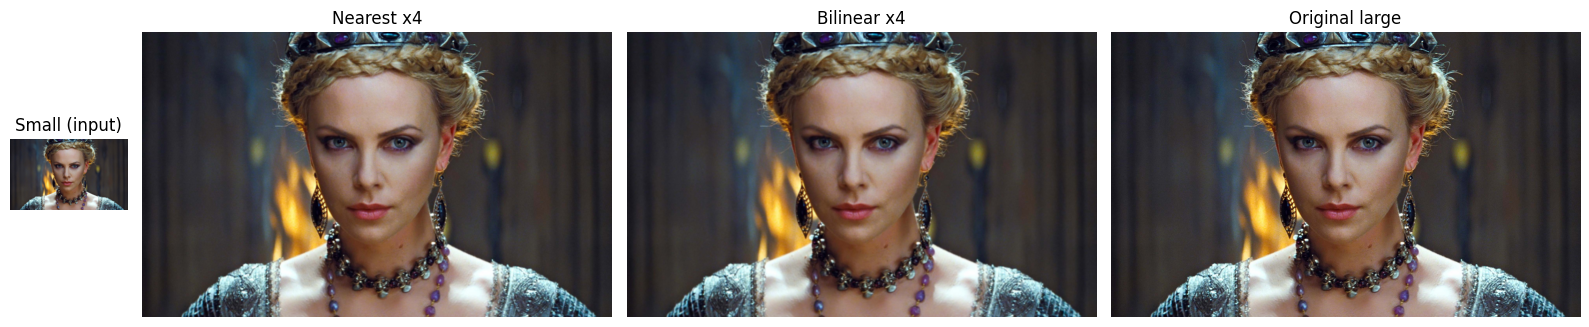

im04small.jpg: nearest neighbor SSD = 228.622, bilinear SSD = 196.766


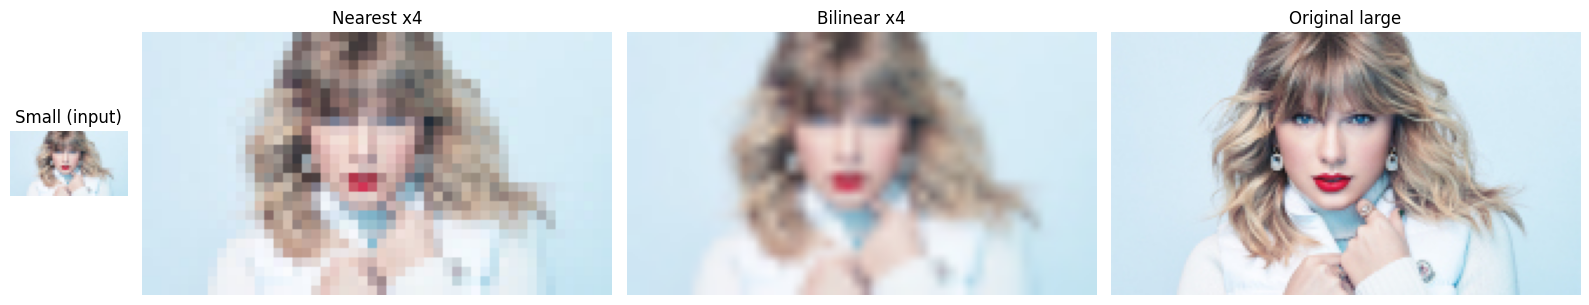

In [89]:
from matplotlib.gridspec import GridSpec

def zoom_image(im, s, method):
    assert 0 < s <= 10, "s must be in (0, 10]"
    im_f = im.astype(np.float64)
    H, W = im.shape[:2]
    new_H, new_W = max(1, round(H * s)), max(1, round(W * s))

    ys = (np.arange(new_H) + 0.5) / s - 0.5
    xs = (np.arange(new_W) + 0.5) / s - 0.5

    if method == "nearest":
        y_idx = np.clip(np.round(ys), 0, H - 1).astype(int)
        x_idx = np.clip(np.round(xs), 0, W - 1).astype(int)
        out = im_f[np.ix_(y_idx, x_idx)]

    elif method == "bilinear":
        y0 = np.clip(np.floor(ys), 0, H - 1).astype(int)
        x0 = np.clip(np.floor(xs), 0, W - 1).astype(int)
        y1 = np.clip(y0 + 1, 0, H - 1)
        x1 = np.clip(x0 + 1, 0, W - 1)

        wy = np.clip(ys - y0, 0, 1)
        wx = np.clip(xs - x0, 0, 1)

        Ia = im_f[np.ix_(y0, x0)]
        Ib = im_f[np.ix_(y0, x1)]
        Ic = im_f[np.ix_(y1, x0)]
        Id = im_f[np.ix_(y1, x1)]

        wy_ = wy[:, None]
        wx_ = wx[None, :]
        if im_f.ndim == 3:
            wy_ = wy_[..., None]
            wx_ = wx_[..., None]
        top = Ia * (1 - wx_) + Ib * wx_
        bottom = Ic * (1 - wx_) + Id * wx_
        out = top * (1 - wy_) + bottom * wy_

    return np.clip(out, 0, 255).astype(im.dtype)


def normalized_ssd(im1, im2):
    a = im1.astype(np.float64)
    b = im2.astype(np.float64)
    return np.sum((a - b) ** 2) / a.size


def task_08():
    pairs = [
        ("images/im01small.png", "images/im01.png"),
        ("images/im02small.png", "images/im02.png"),
        ("images/im03small.png", "images/im03.png"),
        ("images/im04small.jpg", "images/im04.jpg"),
    ]

    for small_path, large_path in pairs:
        small_bgr = cv.imread(small_path)
        large_bgr = cv.imread(large_path)
        if small_bgr is None or large_bgr is None:
            print(f"missing pair: {small_path}, {large_path}")
            break

        small = cv.cvtColor(small_bgr, cv.COLOR_BGR2RGB)
        large = cv.cvtColor(large_bgr, cv.COLOR_BGR2RGB)

        up_nn = zoom_image(small, 4, method="nearest")
        up_bl = zoom_image(small, 4, method="bilinear")

        h = min(up_nn.shape[0], large.shape[0])
        w = min(up_nn.shape[1], large.shape[1])

        ssd_nn = normalized_ssd(up_nn[:h, :w], large[:h, :w])
        ssd_bl = normalized_ssd(up_bl[:h, :w], large[:h, :w])

        print(f"{small_path[7:]}: nearest neighbor SSD = {ssd_nn:.3f}, bilinear SSD = {ssd_bl:.3f}")

        imgs = [small, up_nn[:h, :w], up_bl[:h, :w], large[:h, :w]]
        titles = ["Small (input)", "Nearest x4", "Bilinear x4", "Original large"]

        widths = [im.shape[1] for im in imgs]
        fig = plt.figure(figsize=(16, 4))
        gs = GridSpec(1, 4, width_ratios=widths, figure=fig)
        axes = [fig.add_subplot(gs[i]) for i in range(4)]

        for ax, im, title in zip(axes, imgs, titles):
            ax.imshow(im)
            ax.set_title(title)
            ax.axis("off")
        plt.tight_layout()
        plt.show()

task_08()

### Task 09

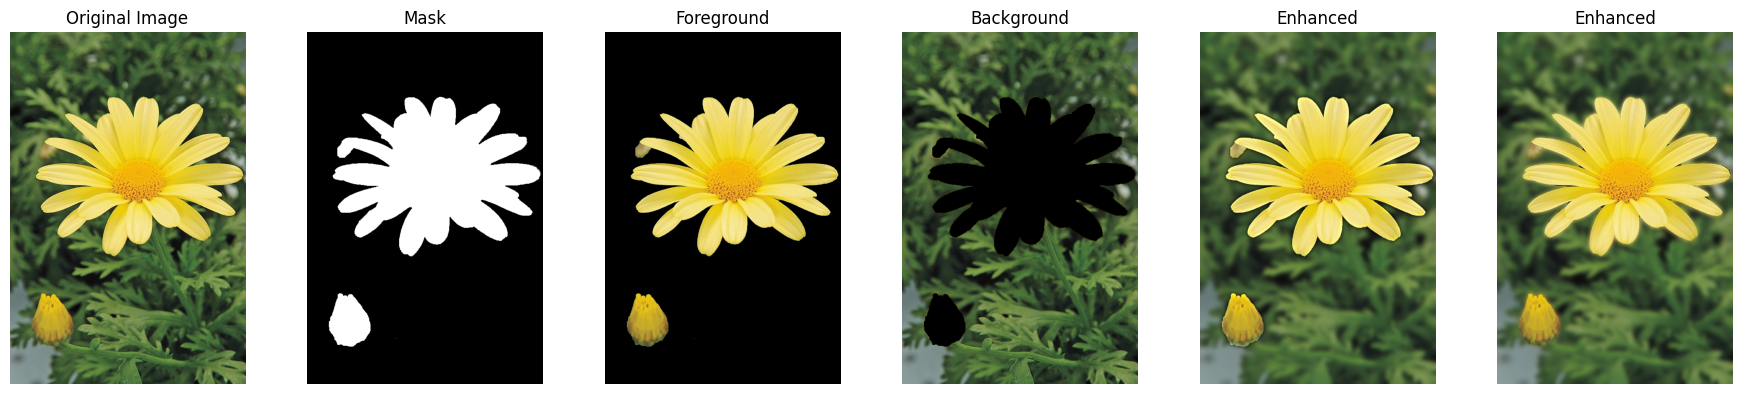

In [90]:
def task_09():
    img_flower = cv.imread("./images/q9.jpeg", cv.IMREAD_COLOR)
    assert img_flower is not None

    mask = np.zeros(img_flower.shape[:2], dtype=np.uint8)
    bgdModel = np.zeros((1, 65), np.float64); fgdModel = np.zeros((1, 65), np.float64)

    h, w = img_flower.shape[:2]
    margin_x, margin_y = int(0.01 * w), int(0.05 * h)
    rect = (margin_x, margin_y, w - 2 * margin_x, h - 2 * margin_y)

    cv.grabCut(img_flower, mask, rect, bgdModel, fgdModel, 5, cv.GC_INIT_WITH_RECT)

    mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')
    foreground = img_flower * mask2[:, :, np.newaxis]
    background = img_flower * (1 - mask2[:, :, np.newaxis])

    blurred_full = cv.GaussianBlur(img_flower, (31, 31), 0)

    mask2_f = mask2[:, :, np.newaxis].astype(np.float32)
    enhanced_image = (img_flower.astype(np.float32) * mask2_f +
                    blurred_full.astype(np.float32) * (1 - mask2_f)).astype(np.uint8)

    blurred_bgd = cv.GaussianBlur(background, (31, 31), 0)
    enhanced_image_naive = cv.add(foreground, blurred_bgd)

    fig, ax = plt.subplots(1, 6, figsize=(18, 4))
    ax[0].imshow(cv.cvtColor(img_flower, cv.COLOR_BGR2RGB)); ax[0].set_title('Original Image')
    ax[1].imshow(mask2, cmap='gray'); ax[1].set_title('Mask')
    ax[2].imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB)); ax[2].set_title('Foreground')
    ax[3].imshow(cv.cvtColor(background, cv.COLOR_BGR2RGB)); ax[3].set_title('Background')
    ax[4].imshow(cv.cvtColor(enhanced_image_naive, cv.COLOR_BGR2RGB)); ax[4].set_title('Enhanced')
    ax[5].imshow(cv.cvtColor(enhanced_image, cv.COLOR_BGR2RGB)); ax[5].set_title('Enhanced')
    for a in ax[1:]: a.axis('off')
    ax[0].axis('off')
    plt.tight_layout();
    plt.show()

task_09()

(c) The dark boundary create because of the Gaussian blurring averages neighboring pixel values within a spatial filter kernel. During blurring dark tones from the flower's edges and shadows bleed outward into near background pixels. When the sharp foreground is overlayed these darkened background boundary pixels  creating an edge effect.

### Task 10

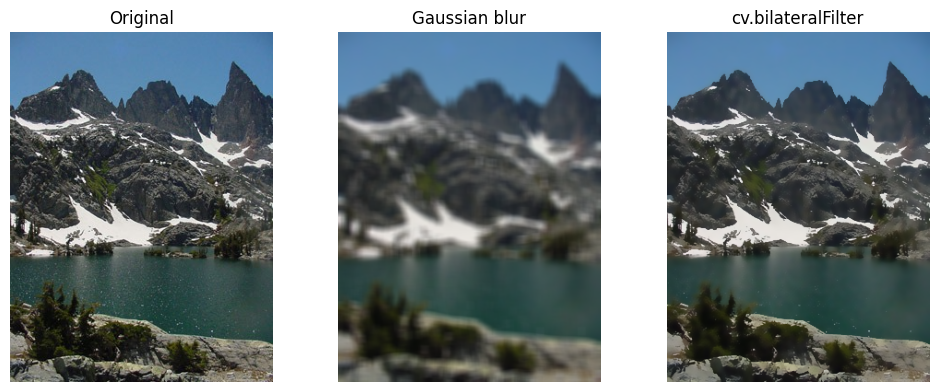

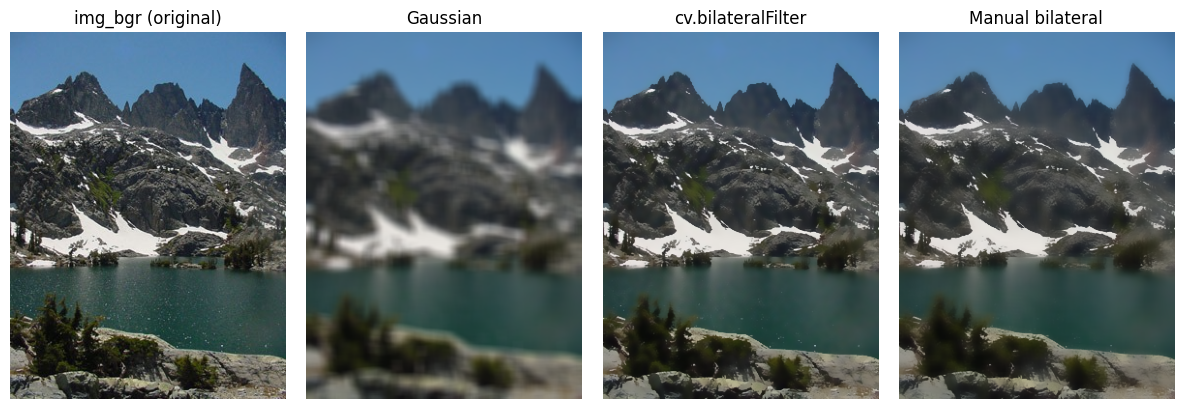

PSNR (manual vs cv.bilateralFilter): 32.51 dB


In [91]:
def bilateral_filter_manual(im, sigma_s, sigma_r, radius=None):
    if radius is None:
        radius = int(2 * sigma_s)

    im_f = im.astype(np.float64)
    H, W, C = im_f.shape
    padded = cv.copyMakeBorder(im_f, radius, radius, radius, radius, cv.BORDER_REFLECT)
    ax = np.arange(-radius, radius + 1)
    gx, gy = np.meshgrid(ax, ax)
    spatial_weights = np.exp(-(gx ** 2 + gy ** 2) / (2 * sigma_s ** 2))

    out = np.zeros_like(im_f)

    for i in range(H):
        for j in range(W):
            patch = padded[i:i + 2 * radius + 1, j:j + 2 * radius + 1, :]
            center = padded[i + radius, j + radius, :]
            diff = patch - center
            range_weights = np.exp(-np.sum(diff ** 2, axis=2) / (2 * sigma_r ** 2))
            weights = spatial_weights * range_weights
            weights_sum = weights.sum()
            out[i, j, :] = (patch * weights[..., None]).sum(axis=(0, 1)) / weights_sum

    return np.clip(out, 0, 255).astype(np.uint8)


def psnr(im1, im2):
    mse = np.mean((im1.astype(np.float64) - im2.astype(np.float64)) ** 2)
    if mse == 0:
        return float("inf")
    return 20 * np.log10(255.0 / np.sqrt(mse))


def task_10():
    img_bgr = load_image("images/q10.jpeg", False)
    lake_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    sigma_s, sigma_r = 15, 75  # spatial / range sigmas tune for visible edge- preserving smoothing

    bilateral_cv = cv.bilateralFilter(img_bgr, d=9, sigmaColor=sigma_r, sigmaSpace=sigma_s)
    gaussian_cv = cv.GaussianBlur(img_bgr, (9, 9), sigmaX=sigma_s)

    fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    imgs = [lake_rgb, cv.cvtColor(gaussian_cv, cv.COLOR_BGR2RGB), cv.cvtColor(bilateral_cv, cv.COLOR_BGR2RGB)]
    titles = ["Original", "Gaussian blur", "cv.bilateralFilter"]
    for ax, im, title in zip(axes, imgs, titles):
        ax.imshow(im)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    img_bgr_bilateral_manual = bilateral_filter_manual(img_bgr, sigma_s, sigma_r, radius=5)
    img_bgr_bilateral_cv = cv.bilateralFilter(img_bgr, d=9, sigmaColor=sigma_r, sigmaSpace=sigma_s)
    img_bgr_gaussian = cv.GaussianBlur(img_bgr, (11, 11), sigmaX=sigma_s)

    fig, axes = plt.subplots(1, 4, figsize=(12, 4))
    imgs = [
        cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB),
        cv.cvtColor(img_bgr_gaussian, cv.COLOR_BGR2RGB),
        cv.cvtColor(img_bgr_bilateral_cv, cv.COLOR_BGR2RGB),
        cv.cvtColor(img_bgr_bilateral_manual, cv.COLOR_BGR2RGB),
    ]
    titles = ["img_bgr (original)", "Gaussian", "cv.bilateralFilter", "Manual bilateral"]
    for ax, im, title in zip(axes, imgs, titles):
        ax.imshow(im)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"PSNR (manual vs cv.bilateralFilter): {psnr(img_bgr_bilateral_manual, img_bgr_bilateral_cv):.2f} dB")


task_10()